### EDA of final dataset

In [23]:
# === Packages
import pandas as pd
import numpy as np
from seaborn import histplot
from matplotlib.pyplot import subplots, axvline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [2]:
# Read dataset
df = pd.read_csv('../data/final_datasets/raw_reduced_training_data.csv')

In [3]:
df.head()

,gndvi_median_res10,datt1_median_res10,fs_median_res10,siwsi_median_res10,ndmi_median_res10,si_median_res10,w_median_res10,evi_median_res10,lst_median_res10,polygon_area,polygon_perimeter,polygon_density,air_temperature_at_surface [degC],UHI Index
0,0.226649,0.559904,0.834542,-0.023708,0.011038,2.000000,-552.00720,1.335894,40.762629,7.619243e-12,0.000014,32.0,26.644576,1.030289
1,0.226649,0.559904,0.834542,-0.023708,0.011038,2.000000,-552.00720,1.335894,40.762629,7.619243e-12,0.000014,31.0,26.644576,1.030289
2,0.462794,0.758538,0.733204,0.185049,0.182898,0.480226,-341.93740,1.777562,39.926923,2.010406e-10,0.000117,32.0,26.644576,1.023798
3,0.483479,0.733288,0.733204,0.185049,0.173959,0.652482,-381.95745,1.857962,39.926923,2.010406e-10,0.000117,32.0,26.644576,1.023798
4,0.478112,0.745955,0.746522,0.149468,0.143840,-0.053140,-484.02280,2.475712,39.550941,2.010406e-10,0.000117,32.0,26.644576,1.021634


In [4]:
# Check all columns names
for col in df.columns:
    print(col)

gndvi_median_res10
datt1_median_res10
fs_median_res10
siwsi_median_res10
ndmi_median_res10
si_median_res10
w_median_res10
evi_median_res10
lst_median_res10
polygon_area
polygon_perimeter
polygon_density
air_temperature_at_surface [degC]
UHI Index


In [5]:
# Statistical description of the dataset
df.describe()

,gndvi_median_res10,datt1_median_res10,fs_median_res10,siwsi_median_res10,ndmi_median_res10,si_median_res10,w_median_res10,evi_median_res10,lst_median_res10,polygon_area,polygon_perimeter,polygon_density,air_temperature_at_surface [degC],UHI Index
count,11229.000000,11227.000000,11229.000000,11229.000000,11229.000000,11226.000000,11229.000000,11229.000000,11229.000000,1.122900e+04,11229.000000,11229.000000,11229.000000,11229.000000
mean,0.225783,0.245086,0.847365,0.015862,-0.009703,2.301488,-719.383712,1.039231,38.736647,7.432314e-11,0.000040,21.457298,26.985717,1.000001
std,0.175793,13.542193,0.114139,0.108804,0.132000,11.245002,419.157800,4.297828,2.530493,9.695435e-11,0.000037,14.102242,0.414890,0.016238
min,-0.187701,-467.000000,0.430006,-0.263642,-0.558525,-551.000000,-3622.744200,-194.000000,30.117206,0.000000e+00,0.000000,0.000000,26.197958,0.956122
25%,0.095206,0.157163,0.799305,-0.058147,-0.096386,0.875000,-922.012400,0.340114,37.452277,8.290772e-12,0.000013,12.000000,26.716900,0.988577
50%,0.165601,0.704268,0.875716,-0.012691,-0.024390,2.049355,-658.653200,0.828185,38.986968,3.523723e-11,0.000030,19.000000,26.984223,1.000237
75%,0.309578,0.917404,0.925828,0.060644,0.063419,3.265795,-446.502250,1.700381,40.302905,9.911428e-11,0.000057,28.000000,27.180084,1.011176
max,0.806583,407.000000,1.095450,0.413566,0.443110,347.000000,1063.897500,89.375000,49.991283,8.367528e-10,0.000215,86.000000,28.304176,1.046036


In [6]:
# Check NaNs
df.isna().sum()

gndvi_median_res10                   0
datt1_median_res10                   2
fs_median_res10                      0
siwsi_median_res10                   0
ndmi_median_res10                    0
si_median_res10                      3
w_median_res10                       0
evi_median_res10                     0
lst_median_res10                     0
polygon_area                         0
polygon_perimeter                    0
polygon_density                      0
air_temperature_at_surface [degC]    0
UHI Index                            0
dtype: int64

In [7]:
# Check if there are duplicated data in the dataset
df.duplicated().sum()

np.int64(809)

In [8]:
# Print info on each variable
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11229 entries, 0 to 11228
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gndvi_median_res10                 11229 non-null  float64
 1   datt1_median_res10                 11227 non-null  float64
 2   fs_median_res10                    11229 non-null  float64
 3   siwsi_median_res10                 11229 non-null  float64
 4   ndmi_median_res10                  11229 non-null  float64
 5   si_median_res10                    11226 non-null  float64
 6   w_median_res10                     11229 non-null  float64
 7   evi_median_res10                   11229 non-null  float64
 8   lst_median_res10                   11229 non-null  float64
 9   polygon_area                       11229 non-null  float64
 10  polygon_perimeter                  11229 non-null  float64
 11  polygon_density                    11229 non-null  flo

In [17]:
# Check linear correlation between each variable
pearson_cor = df.corr(method = 'pearson').to_numpy()
spearman_cor = df.corr(method = 'spearman').to_numpy()

In [9]:
df.corr(method = 'spearman')

,gndvi_median_res10,datt1_median_res10,fs_median_res10,siwsi_median_res10,ndmi_median_res10,si_median_res10,w_median_res10,evi_median_res10,lst_median_res10,polygon_area,polygon_perimeter,polygon_density,air_temperature_at_surface [degC],UHI Index
gndvi_median_res10,1.000000,0.142918,-0.671398,0.726687,0.636241,-0.521219,0.169448,0.803352,-0.372278,-0.104873,-0.083307,-0.100120,0.038446,-0.232421
datt1_median_res10,0.142918,1.000000,-0.278869,0.301399,0.597722,-0.115481,0.635884,0.128645,-0.160119,-0.019331,-0.019684,-0.072616,-0.003283,-0.101122
fs_median_res10,-0.671398,-0.278869,1.000000,-0.810145,-0.651962,0.467764,-0.505681,-0.574978,0.375675,0.128641,0.116400,0.176008,0.004676,0.236692
siwsi_median_res10,0.726687,0.301399,-0.810145,1.000000,0.779155,-0.510105,0.529285,0.643608,-0.390004,-0.132742,-0.116655,-0.145995,0.014456,-0.237564
ndmi_median_res10,0.636241,0.597722,-0.651962,0.779155,1.000000,-0.483460,0.755254,0.564545,-0.340682,-0.102145,-0.092493,-0.149925,0.001856,-0.196927
si_median_res10,-0.521219,-0.115481,0.467764,-0.510105,-0.483460,1.000000,-0.220129,-0.599258,0.286780,0.109267,0.090351,0.120992,0.008932,0.147687
w_median_res10,0.169448,0.635884,-0.505681,0.529285,0.755254,-0.220129,1.000000,0.181009,-0.217573,-0.089529,-0.098322,-0.226028,-0.066076,-0.133222
evi_median_res10,0.803352,0.128645,-0.574978,0.643608,0.564545,-0.599258,0.181009,1.000000,-0.337792,-0.092561,-0.068615,-0.087109,0.026235,-0.203256
lst_median_res10,-0.372278,-0.160119,0.375675,-0.390004,-0.340682,0.286780,-0.217573,-0.337792,1.000000,0.026971,0.009135,0.319586,0.063673,0.352123
polygon_area,-0.104873,-0.019331,0.128641,-0.132742,-0.102145,0.109267,-0.089529,-0.092561,0.026971,1.000000,0.979901,0.082849,0.031311,-0.019563


In [10]:
df.corr(method = 'spearman')['UHI Index']

gndvi_median_res10                  -0.232421
datt1_median_res10                  -0.101122
fs_median_res10                      0.236692
siwsi_median_res10                  -0.237564
ndmi_median_res10                   -0.196927
si_median_res10                      0.147687
w_median_res10                      -0.133222
evi_median_res10                    -0.203256
lst_median_res10                     0.352123
polygon_area                        -0.019563
polygon_perimeter                   -0.004693
polygon_density                      0.328220
air_temperature_at_surface [degC]    0.120553
UHI Index                            1.000000
Name: UHI Index, dtype: float64

<Axes: xlabel='UHI Index', ylabel='Count'>

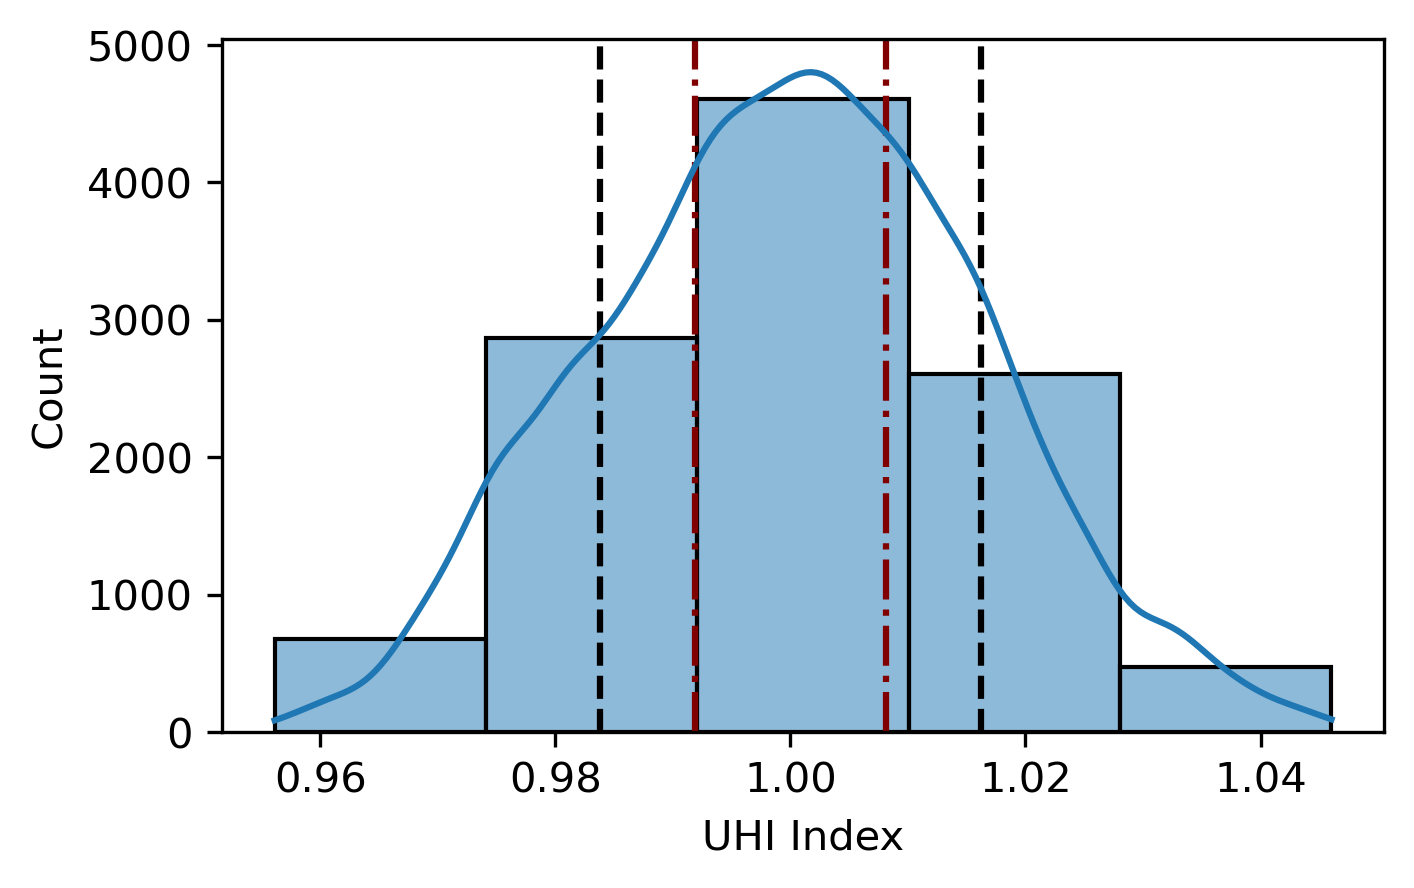

In [29]:
# Std deviation
sigma = 0.016238

# Plot
fig, ax = subplots(1, 1, figsize = (5, 3), dpi = 300)
axvline(x = 1.0 + sigma, color = 'black', ls = '--')
axvline(x = 1.0 - sigma, color = 'black', ls = '--')
axvline(x = 1.0 + sigma/2.0, color = 'maroon', ls = '-.')
axvline(x = 1.0 - sigma/2.0, color = 'maroon', ls = '-.')
histplot(data = df, x = "UHI Index", bins = 5, kde=True, ax = ax)

In [ ]:
# Pipeline to apply to training numerical predictors
numerical_pipeline = Pipeline(steps = [("imputer", SimpleImputer(strategy = "mean")),
                                       ("scaler", StandardScaler())])

In [33]:
preprocessor = ColumnTransformer([("numerical_pipeline", numerical_pipeline, df.columns[:-1])])

In [34]:
input_feature_df = df.drop(columns = ["UHI Index"], axis = 1)

In [35]:
input_feature_arr = preprocessor.fit_transform(input_feature_df)

In [36]:
df_new = pd.DataFrame(np.c_[input_feature_arr, np.array(df[df.columns[-1]])])

In [37]:
df_new.describe()

,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
count,1.122900e+04,1.122900e+04,1.122900e+04,1.122900e+04,1.122900e+04,1.122900e+04,1.122900e+04,1.122900e+04,1.122900e+04,1.122900e+04,...,1.122900e+04,1.122900e+04,1.122900e+04,1.122900e+04,1.122900e+04,1.122900e+04,1.122900e+04,1.122900e+04,1.122900e+04,11229.000000
mean,1.113684e-16,1.721147e-16,-2.024879e-17,-1.721147e-16,-1.619903e-16,-3.163874e-19,-3.746026e-16,-1.581937e-18,-1.032688e-15,-4.151002e-16,...,4.049758e-17,-1.012440e-17,4.819212e-15,-2.227367e-16,-8.099516e-17,1.012440e-16,-9.111956e-17,4.252246e-16,6.925087e-15,1.000001
std,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00,...,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00,1.000045e+00,0.016238
min,-1.802053e+00,-2.352210e+00,-3.430550e+00,-3.304033e+00,-1.264304e+00,-4.057692e+01,-2.210739e+00,-3.450752e+01,-2.464051e+00,-2.397492e+00,...,-1.198151e+00,-1.521620e+00,-1.898800e+00,-2.974365e+00,-2.826076e+00,-2.902379e+00,-1.893640e+00,-1.581726e+00,-2.286364e+00,0.956122
25%,-7.448300e-01,-7.428205e-01,-5.539820e-01,-4.766932e-01,-6.027875e-01,-1.439826e-02,-7.755341e-01,-6.493403e-03,-6.869444e-01,-6.266283e-01,...,-7.332177e-01,-6.706536e-01,-6.479516e-01,-3.546362e-01,-4.089594e-01,-5.485985e-01,-9.497612e-01,-8.590872e-01,-7.623247e-01,0.988577
50%,-3.766110e-01,-3.423621e-01,1.112694e-01,3.423621e-01,-3.839961e-01,2.645064e-02,-3.453195e-01,3.390456e-02,-9.664745e-02,-2.084183e-02,...,-3.172526e-01,-1.742565e-01,-3.603166e-03,1.087471e-01,1.684275e-01,-9.455080e-02,1.473357e-01,-8.290718e-02,1.417707e-01,1.000237
75%,4.280357e-01,4.766932e-01,6.567120e-01,7.428205e-01,1.430970e-01,4.679694e-02,5.123026e-01,4.965156e-02,5.498154e-01,5.636847e-01,...,5.417618e-01,4.639683e-01,4.684987e-01,3.800331e-01,5.809491e-01,7.389993e-01,8.493940e-01,8.027661e-01,8.584947e-01,1.011176
max,3.278766e+00,3.304033e+00,4.157917e+00,2.352210e+00,5.197402e+00,2.957014e+01,2.988283e+00,3.004013e+01,1.010941e+01,8.855359e+00,...,5.050691e+00,4.576972e+00,3.177989e+00,1.640067e+00,2.172314e+00,1.924177e+00,1.738958e+00,2.078831e+00,1.475298e+00,1.046036
